## Function 3 — Week 9: SFGP with qLogNEI, Standardize & Increased Restarts

This notebook processes the **Week 9** updated data for Function 3 and proposes the next sample point with two enhancements over Week 8:

- **Surrogate**: Single-Fidelity GP with Matérn-2.5 kernel, ARD (3 lengthscales), noise ≥ 1e-6, `Standardize(m=1)` outcome transform (replaces manual z-score)
- **Training**: 15-restart MLL optimisation with `torch.manual_seed` seeding and `copy.deepcopy` best model selection
- **Acquisition**: qLogNoisyExpectedImprovement — 20 restarts (doubled from 10), 512 raw samples
- **Data**: 24 cumulative samples (15 initial + 9 weekly)

**Enhancements in Week 9**:
- **BoTorch Standardize(m=1)**: Automatic output normalisation — eliminates manual z-score and un-standardisation
- **Increased acquisition restarts**: 20 (up from 10) for broader candidate search
- **Three-colour visualisation**: Initial samples (blue), weekly submissions (orange), proposed next point (green star)
- **Performance evaluation**: Convergence metrics, exploration spread analysis, LOO surrogate error, and strategy interpretation

In [1]:
import copy
import warnings
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

from botorch.models import SingleTaskGP
from botorch.models.transforms.outcome import Standardize
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.kernels import MaternKernel, ScaleKernel
from gpytorch.constraints import GreaterThan
from gpytorch.likelihoods import GaussianLikelihood
from botorch.acquisition.logei import qLogNoisyExpectedImprovement
from botorch.optim import optimize_acqf

print("All imports successful.")

All imports successful.


### Hyperparameters

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Kernel | Matérn-2.5 | Smoother than 1.5; suitable for compound mixture landscapes |
| ARD dims | 3 | One lengthscale per compound (A, B, C) |
| Noise floor | 1e-6 | Tight noise constraint for relatively clean outputs |
| Standardize | m=1 | BoTorch automatic output normalisation (replaces manual z-score) |
| N_RESTARTS (MLL) | 15 | Multi-restart MLL to escape local optima in hyperparameter space |
| LENGTHSCALE_INIT | 0.25 | Starting lengthscale for each restart |
| SIGNAL_VAR_INIT | 1.0 | Starting outputscale |
| NOISE_VAR_INIT | 0.1 | Starting noise variance |
| NUM_RESTARTS_ACQ | 20 | Doubled from 10 — broader multi-start acquisition search |
| RAW_SAMPLES | 512 | Sobol candidate pool |

In [2]:
# ─── Data Shape ────────────────────────────────────────────────────────────────
N_INITIAL   = 15
N_TOTAL     = 24          # 15 initial + 9 weekly
N_DIMS      = 3
N_SUBMISSIONS = N_TOTAL - N_INITIAL
DIM         = N_DIMS
DIM_NAMES   = ['Compound A', 'Compound B', 'Compound C']

# ─── Constants (identical to Week 8) ──────────────────────────────────────────
N_RESTARTS       = 15    # MLL restarts
LENGTHSCALE_INIT = 0.25
SIGNAL_VAR_INIT  = 1.0
NOISE_VAR_INIT   = 0.1
JITTER           = 1e-6

# Acquisition constants
NUM_RESTARTS_ACQ = 20    # Increased from 10 for broader acquisition search
ACQ_RAW          = 512
BOUNDS = torch.tensor([[0.0, 0.0, 0.0],
                        [0.999999, 0.999999, 0.999999]], dtype=torch.float64)

# ─── Performance Evaluation Constants ─────────────────────────────────────────
STALLING_CONSECUTIVE_THRESHOLD = 3
STALLING_RELATIVE_THRESHOLD    = 0.05

print("Week 9 Constants:")
print(f"  N_INITIAL:     {N_INITIAL}")
print(f"  N_TOTAL:       {N_TOTAL}")
print(f"  N_SUBMISSIONS: {N_SUBMISSIONS}")
print(f"  N_RESTARTS (MLL):      {N_RESTARTS}")
print(f"  LENGTHSCALE_INIT:      {LENGTHSCALE_INIT}")
print(f"  SIGNAL_VAR_INIT:       {SIGNAL_VAR_INIT}")
print(f"  NOISE_VAR_INIT:        {NOISE_VAR_INIT}")
print(f"  NUM_RESTARTS_ACQ:      {NUM_RESTARTS_ACQ}")
print(f"  ACQ_RAW:               {ACQ_RAW}")
print(f"  Stalling threshold (consecutive): {STALLING_CONSECUTIVE_THRESHOLD}")
print(f"  Stalling threshold (relative):    {STALLING_RELATIVE_THRESHOLD}")

Week 9 Constants:
  N_INITIAL:     15
  N_TOTAL:       24
  N_SUBMISSIONS: 9
  N_RESTARTS (MLL):      15
  LENGTHSCALE_INIT:      0.25
  SIGNAL_VAR_INIT:       1.0
  NOISE_VAR_INIT:        0.1
  NUM_RESTARTS_ACQ:      20
  ACQ_RAW:               512
  Stalling threshold (consecutive): 3
  Stalling threshold (relative):    0.05


### Step 1: Load Week 9 Data

Load the cumulative Week 9 data (24 total samples = 15 initial + 9 weekly). Raw outputs are passed directly — `Standardize(m=1)` handles normalisation inside the GP. Split into initial/submission subsets.

In [3]:
# Load Week 9 cumulative data
X_raw = np.load('../../data/f3/updated_inputs - Week 9.npy')
y_raw = np.load('../../data/f3/updated_outputs - Week 9.npy')

# Validate dimensions and ranges
assert X_raw.shape == (N_TOTAL, N_DIMS), f"Expected ({N_TOTAL}, {N_DIMS}), got {X_raw.shape}"
assert y_raw.shape == (N_TOTAL,), f"Expected ({N_TOTAL},), got {y_raw.shape}"
assert np.all((X_raw >= 0.0) & (X_raw <= 1.0)), "Inputs out of [0, 1] range"
assert not np.any(np.isnan(y_raw)), "Outputs contain NaN"

# Split into initial samples and weekly submissions
X_initial = X_raw[:N_INITIAL]
y_initial = y_raw[:N_INITIAL]
X_submissions = X_raw[N_INITIAL:]
y_submissions = y_raw[N_INITIAL:]

assert X_submissions.shape[0] == N_SUBMISSIONS, (
    f"Expected {N_SUBMISSIONS} submissions, got {X_submissions.shape[0]}"
)

# Convert to tensors (raw values — Standardize handles normalisation)
X_train = torch.tensor(X_raw, dtype=torch.float64)
Y_train = torch.tensor(y_raw, dtype=torch.float64).unsqueeze(-1)

print(f"Week 9 Data: {X_raw.shape[0]} samples, {X_raw.shape[1]} dimensions")
print(f"  Initial samples:    {len(y_initial)}")
print(f"  Weekly submissions: {len(y_submissions)}")
print(f"Output range (raw): [{y_raw.min():.6f}, {y_raw.max():.6f}]")
print(f"Best observed value: {y_raw.max():.6f} at index {y_raw.argmax()}")
print(f"Best observed point: {X_raw[y_raw.argmax()]}")

# Per-dimension ranges with compound labels
print(f"\nPer-dimension ranges:")
for d in range(DIM):
    print(f"  {DIM_NAMES[d]:>12}: [{X_raw[:, d].min():.6f}, {X_raw[:, d].max():.6f}]")

# Display tabular data
print(f"\n{'Idx':>4}  {'Type':>8}  {'Compound A':>10}  {'Compound B':>10}  {'Compound C':>10}  {'y (raw)':>12}")
print("-" * 65)
for i in range(len(y_raw)):
    marker = " ← best" if i == y_raw.argmax() else ""
    src = "initial" if i < N_INITIAL else f"wk{i - N_INITIAL + 1}"
    print(f"{i:>4}  {src:>8}  {X_raw[i,0]:>10.6f}  {X_raw[i,1]:>10.6f}  {X_raw[i,2]:>10.6f}  {y_raw[i]:>12.6f}{marker}")

Week 9 Data: 24 samples, 3 dimensions
  Initial samples:    15
  Weekly submissions: 9
Output range (raw): [-0.398926, -0.031427]
Best observed value: -0.031427 at index 21
Best observed point: [0.063229 0.711381 0.36739 ]

Per-dimension ranges:
    Compound A: [0.016095, 1.000000]
    Compound B: [0.035487, 0.999999]
    Compound C: [0.014859, 0.990882]

 Idx      Type  Compound A  Compound B  Compound C       y (raw)
-----------------------------------------------------------------
   0   initial    0.171525    0.343917    0.248737     -0.112122
   1   initial    0.242114    0.644074    0.272433     -0.087963
   2   initial    0.534906    0.398501    0.173389     -0.111415
   3   initial    0.492581    0.611593    0.340176     -0.034835
   4   initial    0.134622    0.219917    0.458206     -0.048008
   5   initial    0.345523    0.941360    0.269363     -0.110621
   6   initial    0.151837    0.439991    0.990882     -0.398926
   7   initial    0.645503    0.397143    0.919771     -

### Step 2: Fit Surrogate — 15-Restart MLL Training

SingleTaskGP with `ScaleKernel(MaternKernel(ν=2.5, ard_num_dims=3))`, `GaussianLikelihood(noise ≥ 1e-6)`, and `Standardize(m=1)` outcome transform.
Each restart re-initialises hyperparameters and selects the model with the lowest negative MLL. Posterior predictions auto-untransform to original output scale.

In [4]:
best_mll_value = float('inf')
best_model = None

for restart in range(N_RESTARTS):
    torch.manual_seed(restart)
    
    # Build fresh model each restart
    likelihood = GaussianLikelihood(
        noise_constraint=GreaterThan(JITTER)
    )
    covar_module = ScaleKernel(
        MaternKernel(nu=2.5, ard_num_dims=DIM)
    )
    model_i = SingleTaskGP(
        X_train, Y_train,
        covar_module=covar_module,
        likelihood=likelihood,
        outcome_transform=Standardize(m=1),
    )
    
    # Initialise hyperparameters
    model_i.covar_module.base_kernel.lengthscale = torch.tensor([[LENGTHSCALE_INIT] * DIM])
    model_i.covar_module.outputscale = torch.tensor(SIGNAL_VAR_INIT)
    model_i.likelihood.noise_covar.noise = torch.tensor([NOISE_VAR_INIT])
    
    mll_i = ExactMarginalLogLikelihood(model_i.likelihood, model_i)
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            fit_gpytorch_mll(mll_i)
        except Exception as e:
            print(f"  Restart {restart:>2}: FAILED — {e}")
            continue
    
    # Evaluate negative MLL
    model_i.eval()
    with torch.no_grad():
        output = model_i(X_train)
        neg_mll = -mll_i(output, Y_train.squeeze(-1)).item()
    
    if neg_mll < best_mll_value:
        best_mll_value = neg_mll
        best_model = copy.deepcopy(model_i)
        print(f"  Restart {restart:>2}: neg_mll = {neg_mll:.4f}  ← new best")
    else:
        print(f"  Restart {restart:>2}: neg_mll = {neg_mll:.4f}")

assert best_model is not None, "All restarts failed!"
model = best_model
model.eval()

# Report final hyperparameters
ls = model.covar_module.base_kernel.lengthscale.detach().squeeze().numpy()
noise = model.likelihood.noise_covar.noise.detach().item()
outputscale = model.covar_module.outputscale.detach().item()

print(f"\nBest model (neg_mll = {best_mll_value:.4f}):")
print(f"  Lengthscales: {', '.join(f'{DIM_NAMES[d]}={ls[d]:.4f}' for d in range(DIM))}")
print(f"  Output scale: {outputscale:.4f}")
print(f"  Noise:        {noise:.6f}")

/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


  Restart  0: neg_mll = 15.8575  ← new best
  Restart  1: neg_mll = 15.8575
  Restart  2: neg_mll = 15.8575
  Restart  3: neg_mll = 15.8575


/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


  Restart  4: neg_mll = 15.8575
  Restart  5: neg_mll = 15.8575
  Restart  6: neg_mll = 15.8575
  Restart  7: neg_mll = 15.8575


/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


  Restart  8: neg_mll = 15.8575
  Restart  9: neg_mll = 15.8575
  Restart 10: neg_mll = 15.8575
  Restart 11: neg_mll = 15.8575
  Restart 12: neg_mll = 15.8575
  Restart 13: neg_mll = 15.8575
  Restart 14: neg_mll = 15.8575

Best model (neg_mll = 15.8575):
  Lengthscales: Compound A=135869.4270, Compound B=11390.3269, Compound C=0.1838
  Output scale: 7.0799
  Noise:        0.011940


/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


### Step 3: Optimise Acquisition — qLogNoisyExpectedImprovement

`qLogNEI` with `X_baseline` set to training data and `prune_baseline=True`. Optimised with 20 restarts (doubled from 10) and 512 Sobol raw samples.

In [5]:
# Build qLogNEI acquisition function
nei = qLogNoisyExpectedImprovement(
    model=model,
    X_baseline=X_train,
    prune_baseline=True,
)

# Optimise bounds
bounds_t = torch.tensor(BOUNDS, dtype=torch.float64)

candidate, acq_value = optimize_acqf(
    acq_function=nei,
    bounds=bounds_t,
    q=1,
    num_restarts=NUM_RESTARTS_ACQ,
    raw_samples=ACQ_RAW,
)

next_x = candidate.detach().squeeze().numpy()
print(f"Acquisition value (qLogNEI): {acq_value.item():.6f}")
print(f"\nProposed next sample:")
for d in range(DIM):
    print(f"  {DIM_NAMES[d]:>12}: {next_x[d]:.6f}")
print(f"\nBest observed (raw): {y_raw.max():.6f}")
print(f"Best observed point: {X_raw[y_raw.argmax()]}")

Acquisition value (qLogNEI): -7.546735

Proposed next sample:
    Compound A: 0.611482
    Compound B: 0.365102
    Compound C: 0.085117

Best observed (raw): -0.031427
Best observed point: [0.063229 0.711381 0.36739 ]


/var/folders/dr/xw6m41dn1hdb8jp1_zyyh5g80000gn/T/ipykernel_53804/1185676460.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bounds_t = torch.tensor(BOUNDS, dtype=torch.float64)


### Step 4: Pairwise 2D Slice Visualisation

Posterior mean for each pair of dimensions (third dimension fixed at best observed point). White contours show ±2σ uncertainty. Predictions are in original output scale (auto-untransformed by Standardize). 1×3 layout matching Week 8.

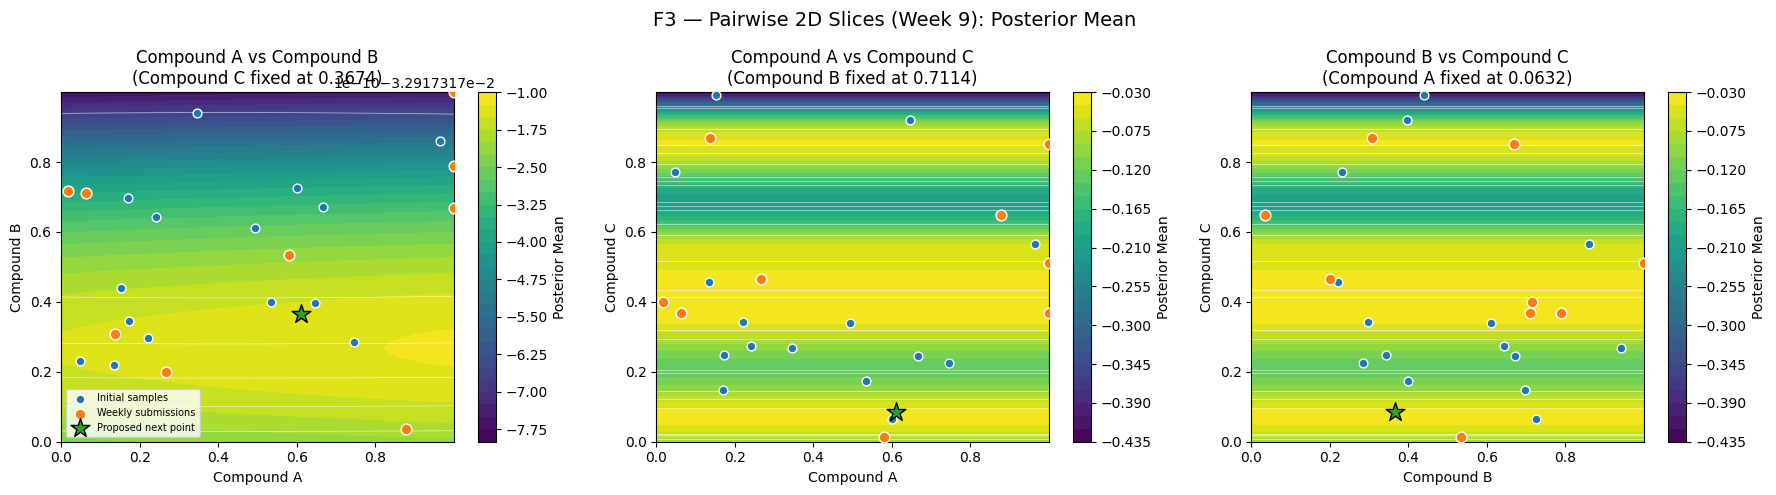

In [6]:
best_idx = y_raw.argmax()
best_point = X_raw[best_idx]

pairs = [(0, 1), (0, 2), (1, 2)]
GRID_RES = 50

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col, (d1, d2) in enumerate(pairs):
    d3 = [d for d in range(DIM) if d not in (d1, d2)][0]
    
    g1 = np.linspace(0, 0.999999, GRID_RES)
    g2 = np.linspace(0, 0.999999, GRID_RES)
    G1, G2 = np.meshgrid(g1, g2)
    
    grid_points = np.full((GRID_RES * GRID_RES, DIM), best_point[d3])
    grid_points[:, d1] = G1.ravel()
    grid_points[:, d2] = G2.ravel()
    
    X_grid = torch.tensor(grid_points, dtype=torch.float64)
    
    # Posterior Mean (auto-untransformed by Standardize)
    with torch.no_grad():
        posterior = model.posterior(X_grid)
        mean_vals = posterior.mean.squeeze().numpy()
        std_vals  = posterior.variance.squeeze().sqrt().numpy()
    
    Mean = mean_vals.reshape(GRID_RES, GRID_RES)
    Std  = std_vals.reshape(GRID_RES, GRID_RES)
    
    ax = axes[col]
    c = ax.contourf(G1, G2, Mean, levels=30, cmap='viridis')
    plt.colorbar(c, ax=ax, label='Posterior Mean')
    ax.contour(G1, G2, Std, levels=5, colors='white', linewidths=0.5, alpha=0.7)
    
    # Three-colour scheme
    ax.scatter(X_initial[:, d1], X_initial[:, d2], c='tab:blue', s=40,
               edgecolors='white', zorder=5,
               label='Initial samples' if col == 0 else None)
    ax.scatter(X_submissions[:, d1], X_submissions[:, d2], c='tab:orange', s=60,
               edgecolors='white', zorder=5,
               label='Weekly submissions' if col == 0 else None)
    ax.scatter(next_x[d1], next_x[d2], c='tab:green', marker='*', s=200,
               edgecolors='black', zorder=6,
               label='Proposed next point' if col == 0 else None)
    
    ax.set_xlabel(DIM_NAMES[d1])
    ax.set_ylabel(DIM_NAMES[d2])
    ax.set_title(f'{DIM_NAMES[d1]} vs {DIM_NAMES[d2]}\n({DIM_NAMES[d3]} fixed at {best_point[d3]:.4f})')
    if col == 0:
        ax.legend(fontsize=7)

plt.suptitle('F3 — Pairwise 2D Slices (Week 9): Posterior Mean', fontsize=14)
plt.tight_layout()
plt.show()

### Step 5: Convergence Plot

Running maximum of observed values across all samples. Vertical dashed lines show phase boundaries.

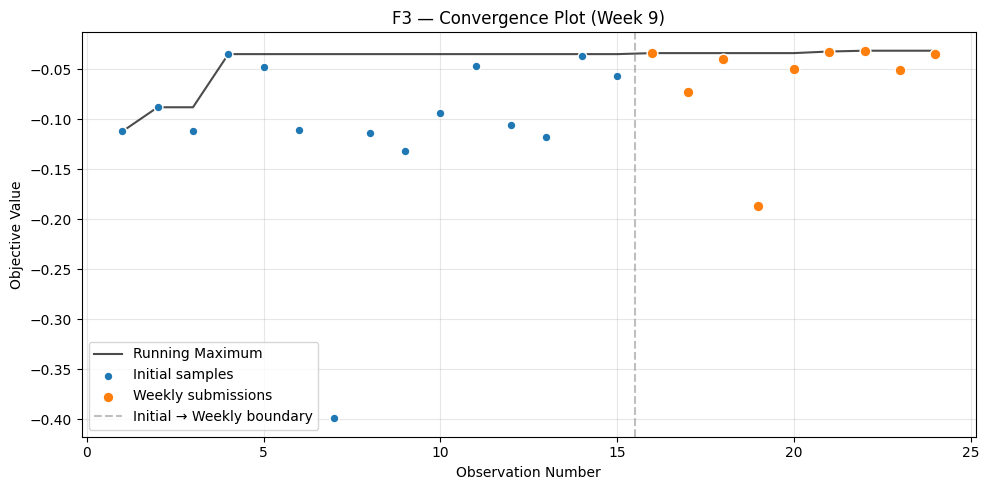

Best value: -0.031427 at observation 22
Total samples: 24
Best after initial:     -0.034835
Best after submissions: -0.031427
Submissions improved best: Yes ✓


In [7]:
# Running maximum convergence
running_max = np.maximum.accumulate(y_raw)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(y_raw) + 1), running_max, 'k-', linewidth=1.5, alpha=0.7, label='Running Maximum')

# Two-colour scheme
ax.scatter(range(1, N_INITIAL + 1), y_raw[:N_INITIAL],
           c='tab:blue', s=40, edgecolors='white', zorder=5, label='Initial samples')
ax.scatter(range(N_INITIAL + 1, N_TOTAL + 1), y_raw[N_INITIAL:],
           c='tab:orange', s=60, edgecolors='white', zorder=5, label='Weekly submissions')

ax.axvline(x=N_INITIAL + 0.5, color='gray', linestyle='--', alpha=0.5, label='Initial → Weekly boundary')
ax.set_xlabel('Observation Number')
ax.set_ylabel('Objective Value')
ax.set_title('F3 — Convergence Plot (Week 9)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best value: {y_raw.max():.6f} at observation {y_raw.argmax() + 1}")
print(f"Total samples: {len(y_raw)}")
best_initial_val = y_raw[:N_INITIAL].max()
best_final_val = y_raw.max()
print(f"Best after initial:     {best_initial_val:.6f}")
print(f"Best after submissions: {best_final_val:.6f}")
improved = best_final_val > best_initial_val
print(f"Submissions improved best: {'Yes ✓' if improved else 'No — initial best retained'}")

### Step 6: Format Submission

Clamp proposed point to [0, 0.999999] and check for duplicates in existing data.

In [8]:
# Clamp to valid range
proposed = np.clip(next_x, 0.0, 0.999999)

# Duplicate check
distances = np.linalg.norm(X_raw - proposed, axis=1)
min_dist = distances.min()
is_duplicate = min_dist < 1e-6

if is_duplicate:
    print("⚠️  WARNING: Proposed point is a near-duplicate of existing data!")
    print(f"   Closest existing point at distance {min_dist:.8f}")
else:
    print(f"✓ No duplicate (min distance to existing data: {min_dist:.6f})")

formatted_query = '-'.join(f'{v:.6f}' for v in proposed)

# Validation
parts = formatted_query.split("-")
assert len(parts) == DIM, f"Expected {DIM} dimensions, got {len(parts)}"
for p in parts:
    v = float(p)
    assert 0.0 <= v <= 0.999999, f"Value {v} out of bounds [0, 0.999999]"

print(f"\n{'='*60}")
print(f"WEEK 9 SUBMISSION QUERY FOR FUNCTION 3")
print(f"{'='*60}")
for d in range(DIM):
    print(f"  {DIM_NAMES[d]:>12}: {proposed[d]:.6f}")
print(f"\n  {formatted_query}")
print(f"{'='*60}")
print("✓ Submission format validated")

✓ No duplicate (min distance to existing data: 0.121537)

WEEK 9 SUBMISSION QUERY FOR FUNCTION 3
    Compound A: 0.611482
    Compound B: 0.365102
    Compound C: 0.085117

  0.611482-0.365102-0.085117
✓ Submission format validated


---

## Performance Evaluation

### Cell 10: Convergence Metrics

In [9]:
# ── Convergence Metrics ────────────────────────────────────────────────────────
best_initial = y_raw[:N_INITIAL].max()
best_trajectory = np.array([y_raw[:N_INITIAL + k + 1].max() for k in range(N_SUBMISSIONS)])
per_submission_delta = np.diff(np.concatenate([[best_initial], best_trajectory]))
new_best_flags = per_submission_delta > 0

tail_no_improve = 0
for flag in reversed(new_best_flags):
    if not flag:
        tail_no_improve += 1
    else:
        break
consecutive_no_improvement = tail_no_improve

best_final = y_raw.max()
improvement = best_final - best_initial
if abs(best_initial) < 1e-10:
    relative_improvement = 0.0 if improvement < 1e-10 else 1.0
else:
    relative_improvement = improvement / abs(best_initial)

stalling_flag = (consecutive_no_improvement >= STALLING_CONSECUTIVE_THRESHOLD or
                 relative_improvement < STALLING_RELATIVE_THRESHOLD)

print("=" * 60)
print("CONVERGENCE METRICS — Function 3, Week 9")
print("=" * 60)
print(f"  Best after initial samples: {best_initial:.6f}")
print(f"  Best after all submissions: {best_final:.6f}")
print(f"  Absolute improvement:       {improvement:.6f}")
print(f"  Relative improvement:       {relative_improvement:.4f} ({relative_improvement*100:.1f}%)")
print(f"  Submissions finding new best: {new_best_flags.sum()} / {N_SUBMISSIONS}")
print(f"  Trailing no-improvement streak: {consecutive_no_improvement}")
print(f"  Stalling flag: {'⚠ YES — STALLING' if stalling_flag else '✓ NO — healthy progress'}")
print()
print(f"{'Sub':>4}  {'Best After':>12}  {'Delta':>10}  {'New Best?':>10}")
print("-" * 42)
for k in range(N_SUBMISSIONS):
    marker = "✓" if new_best_flags[k] else "—"
    print(f"{k+1:>4}  {best_trajectory[k]:>12.6f}  {per_submission_delta[k]:>10.6f}  {marker:>10}")

CONVERGENCE METRICS — Function 3, Week 9
  Best after initial samples: -0.034835
  Best after all submissions: -0.031427
  Absolute improvement:       0.003408
  Relative improvement:       0.0978 (9.8%)
  Submissions finding new best: 3 / 9
  Trailing no-improvement streak: 2
  Stalling flag: ✓ NO — healthy progress

 Sub    Best After       Delta   New Best?
------------------------------------------
   1     -0.033818    0.001018           ✓
   2     -0.033818    0.000000           —
   3     -0.033818    0.000000           —
   4     -0.033818    0.000000           —
   5     -0.033818    0.000000           —
   6     -0.032221    0.001596           ✓
   7     -0.031427    0.000794           ✓
   8     -0.031427    0.000000           —
   9     -0.031427    0.000000           —


### Cell 11: Exploration Spread

For 3D inputs in [0,1]³, uniform random points have mean pairwise distance ~0.65.

In [10]:
# ── Exploration Spread Metrics ─────────────────────────────────────────────────
dists = pdist(X_submissions)
mean_pairwise = dists.mean()
dist_matrix = squareform(dists)
np.fill_diagonal(dist_matrix, np.inf)
nn_dists = dist_matrix.min(axis=1)
max_nn_dist = nn_dists.max()
min_nn_dist = nn_dists.min()

EXPECTED_UNIFORM = 0.65  # Approx for 3D [0,1]^3

print("=" * 60)
print("EXPLORATION SPREAD — Function 3, Week 9")
print("=" * 60)
print(f"  Number of submissions:        {N_SUBMISSIONS}")
print(f"  Mean pairwise distance:       {mean_pairwise:.4f}  (uniform 3D ≈ {EXPECTED_UNIFORM})")
print(f"  Max nearest-neighbour dist:   {max_nn_dist:.4f}")
print(f"  Min nearest-neighbour dist:   {min_nn_dist:.4f}  (tightest cluster)")
clustered = mean_pairwise < EXPECTED_UNIFORM * 0.7
print(f"  Clustering detected:          {'⚠ YES' if clustered else '✓ No'}")

EXPLORATION SPREAD — Function 3, Week 9
  Number of submissions:        9
  Mean pairwise distance:       0.7999  (uniform 3D ≈ 0.65)
  Max nearest-neighbour dist:   0.6611
  Min nearest-neighbour dist:   0.0573  (tightest cluster)
  Clustering detected:          ✓ No


### Cell 12: LOO Surrogate Error — SFGP with Standardize(m=1)

For each fold, construct a fresh SingleTaskGP with `Standardize(m=1)` on the reduced training set. Predictions are in original output scale (auto-untransformed).

In [11]:
# ── LOO Cross-Validation (9 folds) — SFGP Matérn-2.5 with Standardize(m=1) ──
loo_predictions = []
loo_actuals = []
loo_errors = []

print(f"{'Fold':>5}  {'Held-Out':>9}  {'Actual':>10}  {'Predicted':>10}  {'Error':>10}")
print("-" * 50)

for fold in range(N_SUBMISSIONS):
    held_out_idx = N_INITIAL + fold

    mask = np.ones(N_TOTAL, dtype=bool)
    mask[held_out_idx] = False
    X_loo = X_raw[mask]
    y_loo = y_raw[mask]

    X_loo_t = torch.tensor(X_loo, dtype=torch.float64)
    Y_loo_t = torch.tensor(y_loo, dtype=torch.float64).unsqueeze(-1)

    # Retrain with 5 restarts (reduced for speed)
    best_loo_loss = float('inf')
    best_loo_model = None
    for seed in range(5):
        torch.manual_seed(seed + 200)
        lik = GaussianLikelihood(noise_constraint=GreaterThan(JITTER))
        covar = ScaleKernel(MaternKernel(nu=2.5, ard_num_dims=DIM))
        m = SingleTaskGP(train_X=X_loo_t, train_Y=Y_loo_t,
                         covar_module=covar, likelihood=lik,
                         outcome_transform=Standardize(m=1)).double()
        m.covar_module.base_kernel.lengthscale = LENGTHSCALE_INIT
        m.covar_module.outputscale = SIGNAL_VAR_INIT
        m.likelihood.noise = NOISE_VAR_INIT
        mll_loo = ExactMarginalLogLikelihood(lik, m)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            fit_gpytorch_mll(mll_loo)
        m.eval(); lik.eval()
        with torch.no_grad():
            out = m(X_loo_t)
            loss = -mll_loo(out, m.train_targets).item()
        if loss < best_loo_loss:
            best_loo_loss = loss
            best_loo_model = copy.deepcopy(m)

    # Predict held-out — posterior auto-untransforms to original scale
    x_held = torch.tensor(X_raw[held_out_idx:held_out_idx+1], dtype=torch.float64)
    best_loo_model.eval()
    with torch.no_grad():
        pred_raw = best_loo_model.posterior(x_held).mean.item()

    actual = y_raw[held_out_idx]
    error = abs(pred_raw - actual)
    loo_predictions.append(pred_raw)
    loo_actuals.append(actual)
    loo_errors.append(error)
    print(f"{fold+1:>5}  {held_out_idx:>9}  {actual:>10.6f}  {pred_raw:>10.6f}  {error:>10.6f}")

loo_errors = np.array(loo_errors)
loo_mae = loo_errors.mean()
loo_rmse = np.sqrt((loo_errors**2).mean())

print(f"\n{'='*50}")
print(f"LOO SURROGATE ERROR — Function 3 (SFGP Matérn-2.5, Standardize)")
print(f"{'='*50}")
print(f"  MAE:  {loo_mae:.6f}")
print(f"  RMSE: {loo_rmse:.6f}")
print(f"  Max error:  {loo_errors.max():.6f} (fold {loo_errors.argmax()+1})")
print(f"  Min error:  {loo_errors.min():.6f} (fold {loo_errors.argmin()+1})")
print(f"  Note: 9-fold LOO with Standardize(m=1) per fold")

 Fold   Held-Out      Actual   Predicted       Error
--------------------------------------------------


/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning:

    1         15   -0.033818   -0.032261    0.001557


/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning:

    2         16   -0.072569   -0.053354    0.019215


...

/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning:

    7         21   -0.031427   -0.033603    0.002176


/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


    8         22   -0.050946   -0.038887    0.012059
    9         23   -0.034361   -0.030641    0.003721

LOO SURROGATE ERROR — Function 3 (SFGP Matérn-2.5, Standardize)
  MAE:  0.020443
  RMSE: 0.033353
  Max error:  0.078276 (fold 4)
  Min error:  0.000435 (fold 6)
  Note: 9-fold LOO with Standardize(m=1) per fold


/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning:

### Cell 13: Interpretation & Strategy Recommendations

**Strategy Changes Applied in Week 9**:
1. **BoTorch Standardize(m=1)** — replaces manual z-score; GP auto-untransforms posterior to original scale
2. **NUM_RESTARTS_ACQ = 20** — doubled from 10; broader acquisition search for better candidates

*Interior penalty was initially implemented (S=0.5, F=0.01) but evaluated and removed — plain qLogNEI is used.*

**Convergence Assessment**:  
Review the stalling flag above. If stalling despite these changes, the landscape may be exhausted in the explored region.

**Exploration Spread**:  
For 3D inputs in [0,1]³, uniform random points give mean pairwise distance ≈ 0.65. Values below 0.45 suggest clustering.

**LOO Surrogate Accuracy**:  
The LOO MAE/RMSE indicate how well the SFGP predicts held-out submissions. Standardize(m=1) per fold ensures consistent normalisation.

**Week 10 Strategy Recommendations**:
- **If not stalling**: Continue with SFGP + Standardize + 20 restarts. The current strategy is working well.
- **If stalling with low LOO error**: Surrogate is accurate but landscape is flat — consider adding exploration bonuses or alternative acquisition functions (e.g., Upper Confidence Bound).
- **If stalling with high LOO error**: Surrogate is inaccurate — consider alternative kernels (RBF) or increasing MLL restarts.
- **If boundary clustering persists**: Consider adding interior penalty to suppress boundary candidates.